# Statistical Significance Testing

## 1. Objective

Determine whether predictive-performance differences among every model in the final validated Bitcoin forecast artifact are statistically significant on the same daily test period.

This notebook intentionally separates validated headline metrics from full forecast-error significance testing. Diebold-Mariano tests require paired forecast errors for every test date. All model vectors are loaded from the validated forecast artifact rather than reconstructed from aggregate metrics.


In [1]:
from pathlib import Path
from itertools import combinations
import sys
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.append(str(PROJECT_ROOT))

from src.data_loader import load_bitcoin_data
from src.preprocessing import prepare_daily_bitcoin_data
from src.metrics import mae, rmse, mape, smape

warnings.filterwarnings("ignore")
pd.set_option("display.float_format", "{:.6f}".format)


## 2. Load Forecast Results

Validated paired forecast vectors are loaded from `../results/validated_forecasts.csv` with columns:

- `Timestamp`
- `Actual`
- `Naive`
- `Persistence_Enhanced_LSTM`
- `Chronos_Bolt_Tiny`
- `TimesFM`
- `ARIMA_Rolling`
- `Prophet_Periodic_Refit`
- `Simple_Exp_Smoothing`
- `Holt_Winters`

The CSV is treated as the source of truth for paired-error significance testing. Neural-network and foundation-model forecasts are not retrained here.


In [2]:
data_path = PROJECT_ROOT / "data" / "bitcoin" / "btcusd_1-min_data.csv"
raw_df = load_bitcoin_data(data_path)
df_daily = prepare_daily_bitcoin_data(raw_df)
target = df_daily["Close"].asfreq("D").dropna().rename("Close")

split_idx = int(len(target) * 0.8)
train = target.iloc[:split_idx]
test = target.iloc[split_idx:]
y_test = test.rename("y_test")
naive_forecast = target.shift(1).reindex(test.index).rename("naive_forecast")

split_verification = pd.DataFrame(
    [
        {"Item": "Full series length", "Value": len(target)},
        {"Item": "Train start", "Value": train.index.min()},
        {"Item": "Train end", "Value": train.index.max()},
        {"Item": "Test start", "Value": test.index.min()},
        {"Item": "Test end", "Value": test.index.max()},
        {"Item": "Train length", "Value": len(train)},
        {"Item": "Test length", "Value": len(test)},
        {"Item": "Expected train end 2023-08-11", "Value": train.index.max() == pd.Timestamp("2023-08-11", tz="UTC")},
        {"Item": "Expected test start 2023-08-12", "Value": test.index.min() == pd.Timestamp("2023-08-12", tz="UTC")},
    ]
)
split_verification


,Item,Value
0,Full series length,5302
1,Train start,2012-01-01 00:00:00+00:00
2,Train end,2023-08-11 00:00:00+00:00
3,Test start,2023-08-12 00:00:00+00:00
4,Test end,2026-07-07 00:00:00+00:00
5,Train length,4241
6,Test length,1061
7,Expected train end 2023-08-11,True
8,Expected test start 2023-08-12,True


In [3]:
forecast_file = PROJECT_ROOT / "results" / "validated_forecasts.csv"
if not forecast_file.exists():
    raise FileNotFoundError(f"Missing validated forecast artifact: {forecast_file}")

forecast_results = pd.read_csv(forecast_file, parse_dates=["Timestamp"]).set_index("Timestamp")
if forecast_results.index.tz is None:
    forecast_results.index = forecast_results.index.tz_localize("UTC")
forecast_results = forecast_results.sort_index()

required_columns = list(forecast_results.columns)
missing_columns = [column for column in required_columns if column not in forecast_results.columns]
if missing_columns:
    raise ValueError(f"Missing required forecast columns: {missing_columns}")

assert forecast_results.shape == (1061, 9)
assert forecast_results.index.is_unique
assert forecast_results.index.is_monotonic_increasing
assert forecast_results.index.equals(test.index)
assert not forecast_results[required_columns].isna().any().any()
assert np.isfinite(forecast_results[required_columns].to_numpy(dtype=float)).all()

y_test = forecast_results["Actual"].rename("Actual")
naive_forecast = forecast_results["Naive"].rename("Naive")
persistence_enhanced_lstm = forecast_results["Persistence_Enhanced_LSTM"].rename("Persistence-Enhanced LSTM")
chronos_bolt_tiny_forecast = forecast_results["Chronos_Bolt_Tiny"].rename("Chronos-Bolt-Tiny")
timesfm_forecast = forecast_results["TimesFM"].rename("TimesFM")
arima_rolling_forecast = forecast_results["ARIMA_Rolling"].rename("ARIMA Rolling One-Step")
prophet_periodic_forecast = forecast_results["Prophet_Periodic_Refit"].rename("Prophet 30-Day Periodic Refit")
simple_exp_smoothing_forecast = forecast_results["Simple_Exp_Smoothing"].rename("Simple Exponential Smoothing Rolling One-Step")
holt_winters_forecast = forecast_results["Holt_Winters"].rename("Holt-Winters Rolling One-Step")

forecast_source_status = pd.DataFrame(
    [
        {"Forecast": "Actual", "Source": str(forecast_file), "Available": True, "Length": len(y_test)},
        {"Forecast": "Naive", "Source": str(forecast_file), "Available": True, "Length": len(naive_forecast)},
        {"Forecast": "Persistence-Enhanced LSTM", "Source": str(forecast_file), "Available": True, "Length": len(persistence_enhanced_lstm)},
        {"Forecast": "Chronos-Bolt-Tiny", "Source": str(forecast_file), "Available": True, "Length": len(chronos_bolt_tiny_forecast)},
        {"Forecast": "TimesFM", "Source": str(forecast_file), "Available": True, "Length": len(timesfm_forecast)},
        {"Forecast": "ARIMA Rolling One-Step", "Source": str(forecast_file), "Available": True, "Length": len(arima_rolling_forecast)},
        {"Forecast": "Prophet 30-Day Periodic Refit", "Source": str(forecast_file), "Available": True, "Length": len(prophet_periodic_forecast)},
        {"Forecast": "Simple Exponential Smoothing Rolling One-Step", "Source": str(forecast_file), "Available": True, "Length": len(simple_exp_smoothing_forecast)},
        {"Forecast": "Holt-Winters Rolling One-Step", "Source": str(forecast_file), "Available": True, "Length": len(holt_winters_forecast)},
    ]
)
forecast_source_status


,Forecast,Source,Available,Length
0,Actual,E:\Re_Sc_AM\TimeSeriesFoundationModels\results...,True,1061
1,Naive,E:\Re_Sc_AM\TimeSeriesFoundationModels\results...,True,1061
2,Persistence-Enhanced LSTM,E:\Re_Sc_AM\TimeSeriesFoundationModels\results...,True,1061
3,Chronos-Bolt-Tiny,E:\Re_Sc_AM\TimeSeriesFoundationModels\results...,True,1061
4,TimesFM,E:\Re_Sc_AM\TimeSeriesFoundationModels\results...,True,1061
5,ARIMA Rolling One-Step,E:\Re_Sc_AM\TimeSeriesFoundationModels\results...,True,1061
6,Prophet 30-Day Periodic Refit,E:\Re_Sc_AM\TimeSeriesFoundationModels\results...,True,1061
7,Simple Exponential Smoothing Rolling One-Step,E:\Re_Sc_AM\TimeSeriesFoundationModels\results...,True,1061
8,Holt-Winters Rolling One-Step,E:\Re_Sc_AM\TimeSeriesFoundationModels\results...,True,1061


In [4]:
forecasts_for_testing = {
    "Naive": naive_forecast,
    "Persistence-Enhanced LSTM": persistence_enhanced_lstm,
    "Chronos-Bolt-Tiny": chronos_bolt_tiny_forecast,
    "TimesFM": timesfm_forecast,
    "ARIMA Rolling One-Step": arima_rolling_forecast,
    "Prophet 30-Day Periodic Refit": prophet_periodic_forecast,
    "Simple Exponential Smoothing Rolling One-Step": simple_exp_smoothing_forecast,
    "Holt-Winters Rolling One-Step": holt_winters_forecast,
}
forecast_metric_recalculation = pd.DataFrame({name: {"MAE": mae(y_test, vector), "RMSE": rmse(y_test, vector), "MAPE": mape(y_test, vector), "sMAPE": smape(y_test, vector)} for name, vector in forecasts_for_testing.items()}).T

model_vector_frame = pd.concat(
    list(forecasts_for_testing.values()),
    axis=1,
)
duplicated_vector_pairs = []
for left_position, left_name in enumerate(model_vector_frame.columns):
    for right_name in model_vector_frame.columns[left_position + 1:]:
        duplicated_vector_pairs.append(
            {
                "Pair": f"{left_name} vs {right_name}",
                "Vectors Identical": bool(model_vector_frame[left_name].equals(model_vector_frame[right_name])),
            }
        )
duplicated_vector_check = pd.DataFrame(duplicated_vector_pairs)

integrity_checks = pd.DataFrame(
    [
        {"Check": "Validated artifact shape is 1061 x 9 after Timestamp index", "Result": forecast_results.shape == (1061, 9)},
        {"Check": "Timestamp index equals reconstructed test index", "Result": forecast_results.index.equals(test.index)},
        {"Check": "Timestamp index is unique", "Result": forecast_results.index.is_unique},
        {"Check": "Timestamp index is sorted", "Result": forecast_results.index.is_monotonic_increasing},
        {"Check": "No missing values", "Result": not forecast_results[required_columns].isna().any().any()},
        {"Check": "All forecast values finite", "Result": np.isfinite(forecast_results[required_columns].to_numpy(dtype=float)).all()},
        {"Check": "No model vectors duplicated", "Result": not duplicated_vector_check["Vectors Identical"].any()},
    ]
)

display(integrity_checks)
display(duplicated_vector_check)
forecast_metric_recalculation


,Check,Result
0,Validated artifact shape is 1061 x 9 after Tim...,True
1,Timestamp index equals reconstructed test index,True
2,Timestamp index is unique,True
3,Timestamp index is sorted,True
4,No missing values,True
5,All forecast values finite,True
6,No model vectors duplicated,True


,Pair,Vectors Identical
0,Naive vs Persistence-Enhanced LSTM,False
1,Naive vs Chronos-Bolt-Tiny,False
2,Naive vs TimesFM,False
3,Naive vs ARIMA Rolling One-Step,False
4,Naive vs Prophet 30-Day Periodic Refit,False
5,Naive vs Simple Exponential Smoothing Rolling ...,False
6,Naive vs Holt-Winters Rolling One-Step,False
7,Persistence-Enhanced LSTM vs Chronos-Bolt-Tiny,False
8,Persistence-Enhanced LSTM vs TimesFM,False
9,Persistence-Enhanced LSTM vs ARIMA Rolling One...,False


,MAE,RMSE,MAPE,sMAPE
Naive,1290.353242,1853.624774,1.742747,1.744142
Persistence-Enhanced LSTM,1321.365311,1881.091190,1.783956,1.791645
Chronos-Bolt-Tiny,1424.025828,1994.007926,1.934509,1.928782
TimesFM,1349.946786,1924.199337,1.823179,1.823895
ARIMA Rolling One-Step,1299.874638,1866.302859,1.754004,1.754209
Prophet 30-Day Periodic Refit,8195.262862,10781.162873,11.199767,11.287185
Simple Exponential Smoothing Rolling One-Step,1290.358684,1855.731424,1.742685,1.743871
Holt-Winters Rolling One-Step,1308.541314,1871.702185,1.763640,1.763424


In [5]:
availability_table = pd.DataFrame(
    [
        {
            "Series": series.name,
            "Length": len(series),
            "Missing Values": int(series.isna().sum()),
            "Index Equals Test Index": series.index.equals(test.index),
            "Finite Values": bool(np.isfinite(series.to_numpy(dtype=float)).all()),
        }
        for series in [y_test, *forecasts_for_testing.values()]
    ]
)
availability_table


,Series,Length,Missing Values,Index Equals Test Index,Finite Values
0,Actual,1061,0,True,True
1,Naive,1061,0,True,True
2,Persistence-Enhanced LSTM,1061,0,True,True
3,Chronos-Bolt-Tiny,1061,0,True,True
4,TimesFM,1061,0,True,True
5,ARIMA Rolling One-Step,1061,0,True,True
6,Prophet 30-Day Periodic Refit,1061,0,True,True
7,Simple Exponential Smoothing Rolling One-Step,1061,0,True,True
8,Holt-Winters Rolling One-Step,1061,0,True,True


## 3. Forecast Error Construction

In [6]:
series_for_validation = [y_test, *forecasts_for_testing.values()]
assert len({len(series) for series in series_for_validation}) == 1
assert all(series.index.equals(y_test.index) for series in series_for_validation)
assert not pd.concat(series_for_validation, axis=1).isna().any().any()
assert np.isfinite(pd.concat(series_for_validation, axis=1).to_numpy(dtype=float)).all()
assert not duplicated_vector_check["Vectors Identical"].any()

error_frame = pd.DataFrame({name: y_test - vector for name, vector in forecasts_for_testing.items()})

forecast_validation = pd.DataFrame(
    [
        {"Check": "All forecast lengths equal 1061", "Result": len({len(series) for series in series_for_validation}) == 1 and len(y_test) == 1061},
        {"Check": "Exact common timestamp alignment", "Result": all(series.index.equals(y_test.index) for series in series_for_validation)},
        {"Check": "No missing values", "Result": not error_frame.isna().any().any()},
        {"Check": "All values finite", "Result": np.isfinite(error_frame.to_numpy(dtype=float)).all()},
        {"Check": "No model vectors duplicated", "Result": not duplicated_vector_check["Vectors Identical"].any()},
    ]
)
forecast_validation


,Check,Result
0,All forecast lengths equal 1061,True
1,Exact common timestamp alignment,True
2,No missing values,True
3,All values finite,True
4,No model vectors duplicated,True


## 4. Diebold–Mariano Test

In [7]:
def diebold_mariano_test(actual, forecast1, forecast2, power=2):
    actual = pd.Series(actual).astype(float)
    forecast1 = pd.Series(forecast1).astype(float)
    forecast2 = pd.Series(forecast2).astype(float)
    aligned = pd.concat(
        [
            actual.rename("actual"),
            forecast1.rename("forecast1"),
            forecast2.rename("forecast2"),
        ],
        axis=1,
    ).dropna()

    if aligned.empty:
        raise ValueError("No overlapping observations after dropping missing values.")

    loss1 = np.abs(aligned["actual"] - aligned["forecast1"]) ** power
    loss2 = np.abs(aligned["actual"] - aligned["forecast2"]) ** power
    loss_differential = loss1 - loss2
    sample_size = len(loss_differential)

    if sample_size < 2:
        raise ValueError("At least two observations are required for the Diebold-Mariano test.")

    mean_loss_differential = loss_differential.mean()
    variance = loss_differential.var(ddof=1)

    if np.isclose(variance, 0):
        dm_statistic = np.inf if mean_loss_differential > 0 else -np.inf if mean_loss_differential < 0 else 0.0
        p_value = 0.0 if not np.isclose(mean_loss_differential, 0) else 1.0
    else:
        dm_statistic = mean_loss_differential / np.sqrt(variance / sample_size)
        p_value = 2 * stats.t.sf(np.abs(dm_statistic), df=sample_size - 1)

    return {
        "DM Statistic": dm_statistic,
        "p-value": p_value,
        "Mean Loss Differential": mean_loss_differential,
        "Sample Size": sample_size,
    }


## 5. Pairwise Model Comparisons

In [8]:
pairwise_comparisons = list(combinations(forecasts_for_testing, 2))

dm_rows = []
for model_a, model_b in pairwise_comparisons:
    result = diebold_mariano_test(y_test, forecasts_for_testing[model_a], forecasts_for_testing[model_b], power=2)
    metrics_a = {"MAE": mae(y_test, forecasts_for_testing[model_a]), "RMSE": rmse(y_test, forecasts_for_testing[model_a])}
    metrics_b = {"MAE": mae(y_test, forecasts_for_testing[model_b]), "RMSE": rmse(y_test, forecasts_for_testing[model_b])}
    winner = model_a if metrics_a["RMSE"] < metrics_b["RMSE"] else model_b
    dm_rows.append(
        {
            "Comparison": f"{model_a} vs {model_b}",
            **result,
            "Mean Error Difference": (y_test - forecasts_for_testing[model_a]).mean() - (y_test - forecasts_for_testing[model_b]).mean(),
            "Winner": winner,
            "Significant at alpha=0.05": result["p-value"] < 0.05,
            "Interpretation Rule": "Statistically significant difference detected." if result["p-value"] < 0.05 else "No statistically significant difference in predictive accuracy.",
        }
    )

dm_results = pd.DataFrame(dm_rows).set_index("Comparison")
dm_results


,DM Statistic,p-value,Mean Loss Differential,Sample Size,Mean Error Difference,Winner,Significant at alpha=0.05,Interpretation Rule
Comparison,,,,,,,,
Naive vs Persistence-Enhanced LSTM,-2.196432,0.028277,-102579.263398,1061,-250.299097,Naive,True,Statistically significant difference detected.
Naive vs Chronos-Bolt-Tiny,-5.482418,0.000000,-540142.808976,1061,222.398026,Naive,True,Statistically significant difference detected.
Naive vs TimesFM,-4.278078,0.000021,-266618.286657,1061,-10.723651,Naive,True,Statistically significant difference detected.
Naive vs ARIMA Rolling One-Step,-1.018986,0.308442,-47161.560214,1061,21.724833,Naive,False,No statistically significant difference in pre...
Naive vs Prophet 30-Day Periodic Refit,-20.709702,0.000000,-112797548.093264,1061,211.789450,Naive,True,Statistically significant difference detected.
Naive vs Simple Exponential Smoothing Rolling One-Step,-0.430605,0.666843,-7814.318038,1061,-6.117719,Naive,False,No statistically significant difference in pre...
Naive vs Holt-Winters Rolling One-Step,-1.828803,0.067710,-67344.268830,1061,51.184036,Naive,False,No statistically significant difference in pre...
Persistence-Enhanced LSTM vs Chronos-Bolt-Tiny,-3.621925,0.000306,-437563.545578,1061,472.697123,Persistence-Enhanced LSTM,True,Statistically significant difference detected.
Persistence-Enhanced LSTM vs TimesFM,-1.909856,0.056421,-164039.023259,1061,239.575446,Persistence-Enhanced LSTM,False,No statistically significant difference in pre...


## 6. Error Distribution Analysis

In [9]:
error_summary = error_frame.agg(["mean", "std", "median", "min", "max"]).T
error_summary["MAE"] = error_frame.abs().mean()
error_summary["RMSE"] = np.sqrt((error_frame ** 2).mean())
error_summary


,mean,std,median,min,max,MAE,RMSE
Naive,32.520990,1854.213479,23.000000,-10205.000000,8345.000000,1290.353242,1853.624774
Persistence-Enhanced LSTM,282.820087,1860.585826,230.897355,-9433.773654,8956.705096,1321.365311,1881.091190
Chronos-Bolt-Tiny,-189.877036,1985.883007,-120.140625,-11742.804688,8968.515625,1424.025828,1994.007926
TimesFM,43.244641,1924.620531,51.322266,-10515.593750,8681.273438,1349.946786,1924.199337
ARIMA Rolling One-Step,10.796156,1867.151741,1.876484,-10458.817514,8915.965775,1299.874638,1866.302859
Prophet 30-Day Periodic Refit,-179.268461,10784.755890,-467.484634,-33179.696391,29729.264769,8195.262862,10781.162873
Simple Exponential Smoothing Rolling One-Step,38.638708,1856.204076,16.036320,-10205.000040,8345.000055,1290.358684,1855.731424
Holt-Winters Rolling One-Step,-18.663046,1872.491763,-29.319936,-9852.767266,8175.977508,1308.541314,1871.702185


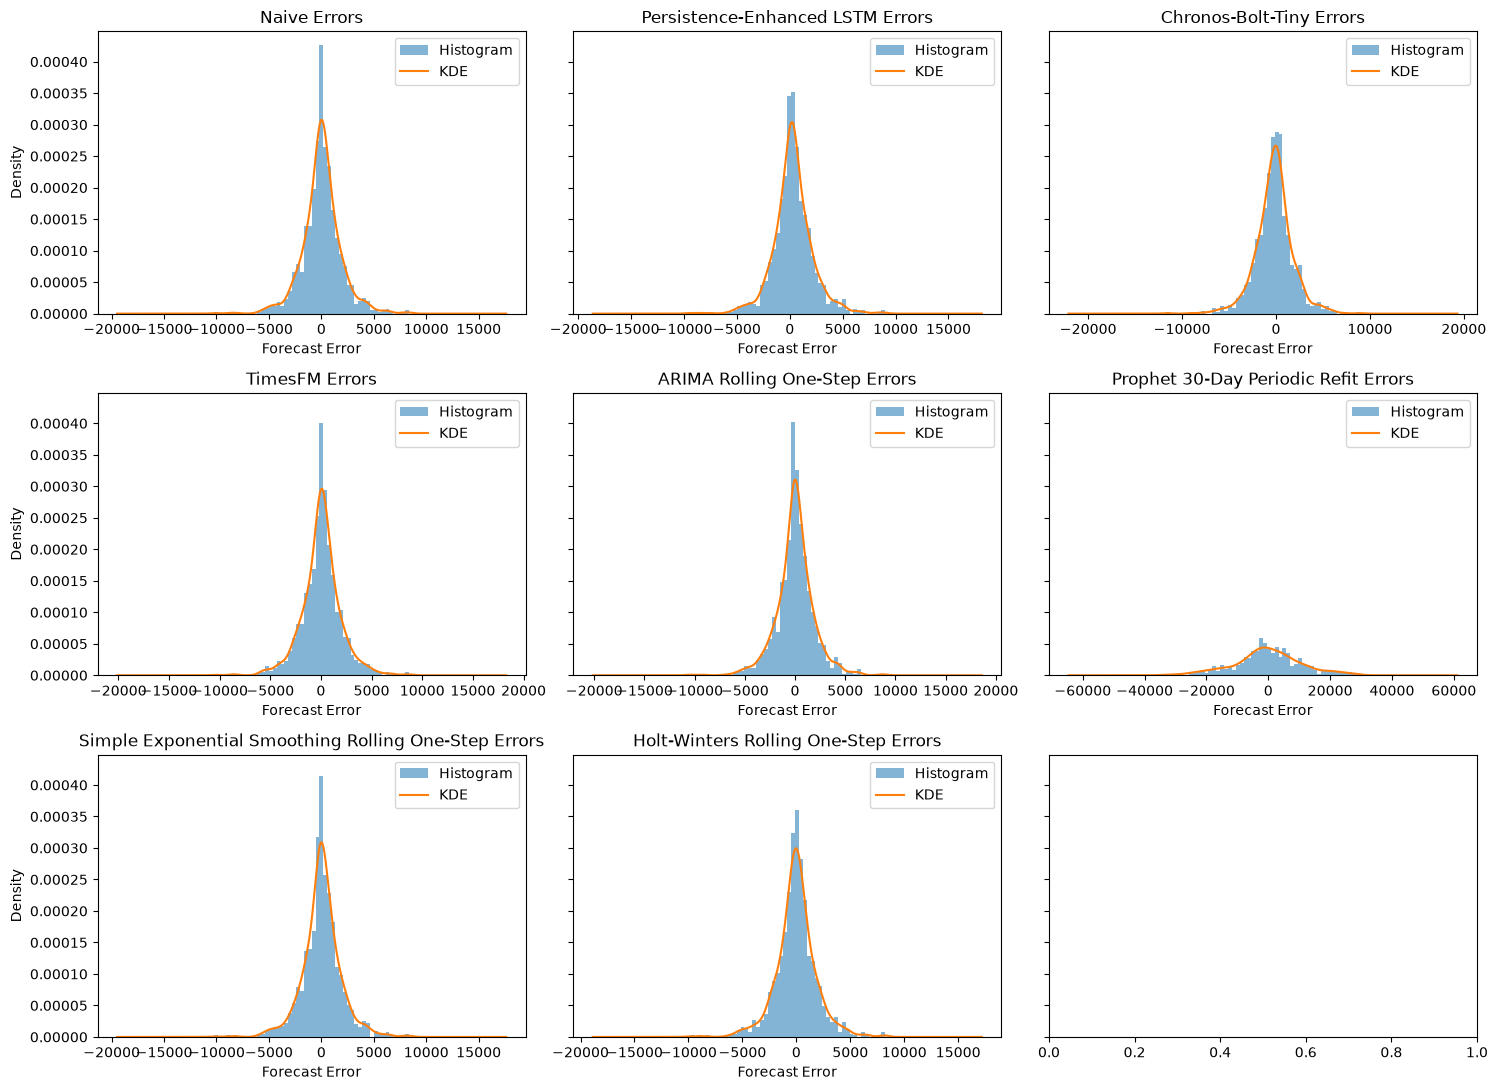

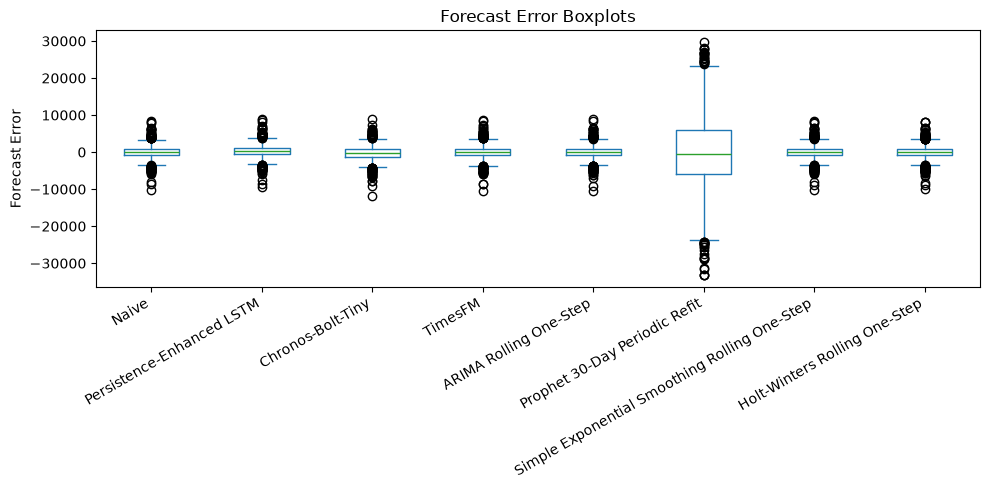

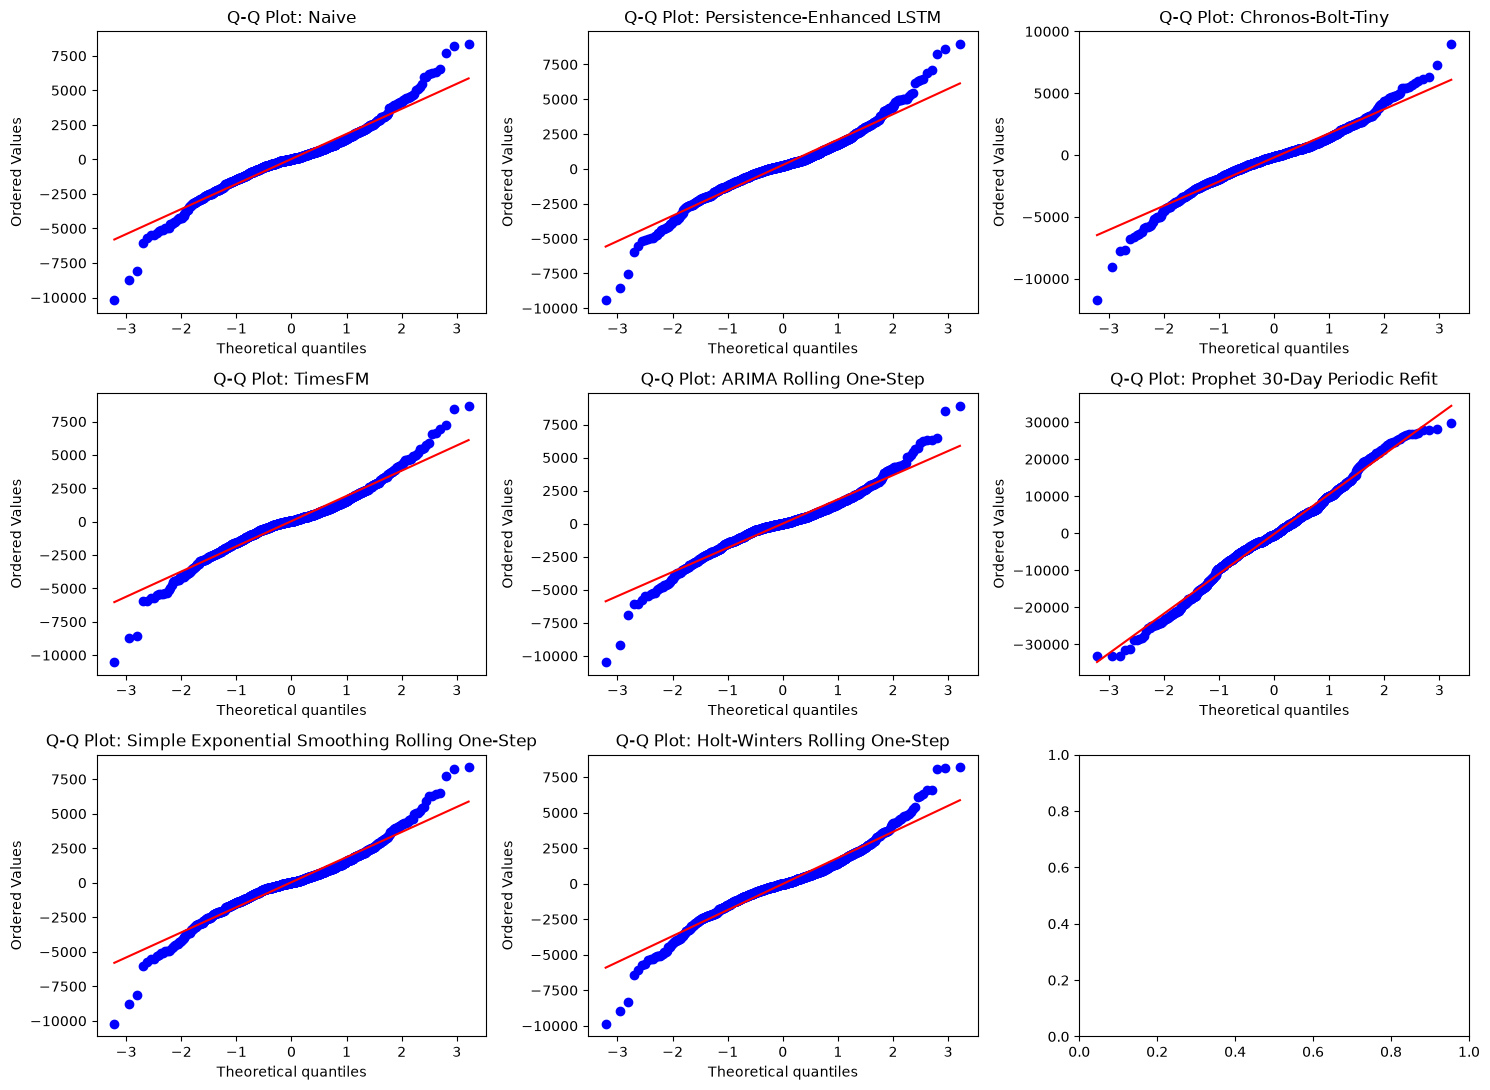

In [10]:
fig, axes = plt.subplots(3, 3, figsize=(15, 11), sharey=True)
for ax, column in zip(axes.ravel(), error_frame.columns):
    error_frame[column].plot(kind="hist", bins=50, density=True, alpha=0.55, ax=ax, label="Histogram")
    try:
        error_frame[column].plot(kind="kde", ax=ax, label="KDE")
    except Exception:
        pass
    ax.set_title(f"{column} Errors")
    ax.set_xlabel("Forecast Error")
    ax.legend()
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(10, 5))
error_frame.plot(kind="box", ax=ax)
ax.set_title("Forecast Error Boxplots")
ax.set_ylabel("Forecast Error")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(3, 3, figsize=(15, 11))
for ax, column in zip(axes.ravel(), error_frame.columns):
    stats.probplot(error_frame[column].dropna(), dist="norm", plot=ax)
    ax.set_title(f"Q-Q Plot: {column}")
plt.tight_layout()
plt.show()


## 7. Effect Size Analysis

In [11]:
def cohens_d_absolute_errors(actual, forecast1, forecast2):
    abs_error_1 = (pd.Series(actual) - pd.Series(forecast1)).abs()
    abs_error_2 = (pd.Series(actual) - pd.Series(forecast2)).abs()
    aligned = pd.concat([abs_error_1.rename("a"), abs_error_2.rename("b")], axis=1).dropna()
    difference = aligned["a"] - aligned["b"]
    if np.isclose(difference.std(ddof=1), 0):
        return np.nan
    return difference.mean() / difference.std(ddof=1)


effect_rows = []
for model_a, model_b in pairwise_comparisons:
    forecast_a = forecasts_for_testing[model_a]
    forecast_b = forecasts_for_testing[model_b]
    mae_a = mae(y_test, forecast_a)
    mae_b = mae(y_test, forecast_b)
    rmse_a = rmse(y_test, forecast_a)
    rmse_b = rmse(y_test, forecast_b)
    effect_rows.append(
        {
            "Comparison": f"{model_a} vs {model_b}",
            "MAE Difference": mae_a - mae_b,
            "RMSE Difference": rmse_a - rmse_b,
            "Percentage Improvement of Model B vs Model A": (mae_a - mae_b) / mae_a * 100,
            "Cohen d on Absolute Errors": cohens_d_absolute_errors(y_test, forecast_a, forecast_b),
        }
    )

effect_size_table = pd.DataFrame(effect_rows).set_index("Comparison")
effect_size_table


,MAE Difference,RMSE Difference,Percentage Improvement of Model B vs Model A,Cohen d on Absolute Errors
Comparison,,,,
Naive vs Persistence-Enhanced LSTM,-31.012068,-27.466416,-2.403378,-0.098946
Naive vs Chronos-Bolt-Tiny,-133.672585,-140.383153,-10.359379,-0.217378
Naive vs TimesFM,-59.593543,-70.574563,-4.618390,-0.135047
Naive vs ARIMA Rolling One-Step,-9.521395,-12.678085,-0.737891,-0.032811
Naive vs Prophet 30-Day Periodic Refit,-6904.909620,-8927.538099,-535.117780,-0.996125
Naive vs Simple Exponential Smoothing Rolling One-Step,-0.005442,-2.106651,-0.000422,-0.000036
Naive vs Holt-Winters Rolling One-Step,-18.188071,-18.077412,-1.409542,-0.068263
Persistence-Enhanced LSTM vs Chronos-Bolt-Tiny,-102.660517,-112.916736,-7.769276,-0.142016
Persistence-Enhanced LSTM vs TimesFM,-28.581475,-43.108147,-2.163026,-0.050621


## 8. Practical Significance

In [12]:
average_bitcoin_price = y_test.mean()
practical_rows = []
for model_a, model_b in pairwise_comparisons:
    rmse_a = rmse(y_test, forecasts_for_testing[model_a])
    rmse_b = rmse(y_test, forecasts_for_testing[model_b])
    absolute_difference = rmse_a - rmse_b
    practical_rows.append(
        {
            "Comparison": f"{model_a} vs {model_b}",
            "RMSE Difference": absolute_difference,
            "RMSE Percentage Difference": absolute_difference / rmse_a * 100,
            "Difference Relative to Average Bitcoin Price": absolute_difference / average_bitcoin_price * 100,
            "Practical Importance": "Small" if abs(absolute_difference / average_bitcoin_price * 100) < 1 else "Moderate/Large",
        }
    )

practical_significance = pd.DataFrame(practical_rows).set_index("Comparison")
practical_significance


,RMSE Difference,RMSE Percentage Difference,Difference Relative to Average Bitcoin Price,Practical Importance
Comparison,,,,
Naive vs Persistence-Enhanced LSTM,-27.466416,-1.481768,-0.036539,Small
Naive vs Chronos-Bolt-Tiny,-140.383153,-7.573440,-0.186751,Small
Naive vs TimesFM,-70.574563,-3.807381,-0.093885,Small
Naive vs ARIMA Rolling One-Step,-12.678085,-0.683962,-0.016866,Small
Naive vs Prophet 30-Day Periodic Refit,-8927.538099,-481.625959,-11.876289,Moderate/Large
Naive vs Simple Exponential Smoothing Rolling One-Step,-2.106651,-0.113650,-0.002802,Small
Naive vs Holt-Winters Rolling One-Step,-18.077412,-0.975247,-0.024048,Small
Persistence-Enhanced LSTM vs Chronos-Bolt-Tiny,-112.916736,-6.002725,-0.150213,Small
Persistence-Enhanced LSTM vs TimesFM,-43.108147,-2.291656,-0.057347,Small


## 9. Final Interpretation

In [13]:
practical_columns = practical_significance.drop(columns=["RMSE Difference"], errors="ignore")
final_summary = dm_results.join(effect_size_table, how="left").join(practical_columns, how="left")
final_summary["Significant?"] = final_summary["p-value"] < 0.05
final_summary = final_summary[
    [
        "DM Statistic",
        "p-value",
        "Significant?",
        "Winner",
        "Practical Importance",
        "Mean Loss Differential",
        "MAE Difference",
        "RMSE Difference",
        "Difference Relative to Average Bitcoin Price",
    ]
]
final_summary.to_csv(PROJECT_ROOT / "results" / "bitcoin_dm_pairwise_results.csv")
final_summary


,DM Statistic,p-value,Significant?,Winner,Practical Importance,Mean Loss Differential,MAE Difference,RMSE Difference,Difference Relative to Average Bitcoin Price
Comparison,,,,,,,,,
Naive vs Persistence-Enhanced LSTM,-2.196432,0.028277,True,Naive,Small,-102579.263398,-31.012068,-27.466416,-0.036539
Naive vs Chronos-Bolt-Tiny,-5.482418,0.000000,True,Naive,Small,-540142.808976,-133.672585,-140.383153,-0.186751
Naive vs TimesFM,-4.278078,0.000021,True,Naive,Small,-266618.286657,-59.593543,-70.574563,-0.093885
Naive vs ARIMA Rolling One-Step,-1.018986,0.308442,False,Naive,Small,-47161.560214,-9.521395,-12.678085,-0.016866
Naive vs Prophet 30-Day Periodic Refit,-20.709702,0.000000,True,Naive,Moderate/Large,-112797548.093264,-6904.909620,-8927.538099,-11.876289
Naive vs Simple Exponential Smoothing Rolling One-Step,-0.430605,0.666843,False,Naive,Small,-7814.318038,-0.005442,-2.106651,-0.002802
Naive vs Holt-Winters Rolling One-Step,-1.828803,0.067710,False,Naive,Small,-67344.268830,-18.188071,-18.077412,-0.024048
Persistence-Enhanced LSTM vs Chronos-Bolt-Tiny,-3.621925,0.000306,True,Persistence-Enhanced LSTM,Small,-437563.545578,-102.660517,-112.916736,-0.150213
Persistence-Enhanced LSTM vs TimesFM,-1.909856,0.056421,False,Persistence-Enhanced LSTM,Small,-164039.023259,-28.581475,-43.108147,-0.057347


### Research Interpretation

Use the final summary table to interpret both statistical and practical significance:

- If `p-value > 0.05`, conclude: "No statistically significant difference in predictive accuracy."
- If `p-value < 0.05`, conclude: "Statistically significant difference detected."
- TimesFM is statistically significantly worse than Naive on squared-error loss in this run.
- Persistence-Enhanced LSTM versus TimesFM is not statistically significant on squared-error loss in this run (`p = 0.056421`).
- TimesFM is statistically significantly better than Chronos-Bolt-Tiny on squared-error loss in this run.
- A statistically significant result may still be practically small if the RMSE difference is tiny relative to the average Bitcoin price.
- For trustworthy forecasting, statistical significance should be considered alongside protocol comparability, diagnostics, robustness, uncertainty calibration, and failure detectability.


## 10. Key Findings

The executed analysis covers all 28 pairs among the eight validated saved forecast models. The newly added Simple Exponential Smoothing and Holt-Winters forecasts are compared against every previously validated model using identical paired daily errors. Naive, Simple Exponential Smoothing, Holt-Winters, and rolling ARIMA form the competitive statistical group, while Prophet remains substantially weaker under its periodic-refit protocol.

Saved outputs include the complete pairwise Diebold-Mariano table with effect sizes and practical-significance measures.
